# SC2001 Project 1 - Integration of Merge Sort & Insertion Sort


#### Prelude: Implementation of the classic Merge Sort and a modified Insertion Sort (both tracks key comparisons)


In [12]:
def merge_sort(numArray: list[int], start: int = 0, end: int = -1) -> int:
    """
    In-place merge sort that arranges array elements in ascending order.

    Args:
        numArray: Target array to be sorted.
        start: The left bound of values for function to focus on.
        end: The right bound of values for function to focus on.

    Returns:
        The number of key comparisons made in the merge sort process.
    """
    # Initialises the start & end values, if they do not exist
    if end == -1:
        end = len(numArray) - 1

    # Prematurely ends function if left bound exceeds right
    if end <= start:
        return 0

    # Splits the array into 2 sections and implement merge sort on each section
    mid = start + (end - start) // 2
    kcomp_l = merge_sort(numArray, start, mid)
    kcomp_r = merge_sort(numArray, mid + 1, end)

    # Sorts every element in the array concurrently in both sections
    kcomp_m = merge(numArray, start, mid, end)

    return kcomp_r + kcomp_m + kcomp_l

def merge(arr: list[int], l: int, m: int, r: int) -> int:
    """
    Helper function for merge sorting.

    Args:
        arr: Array to be sorted.
        l: Left bound.
        m: Middle point.
        r: Right bound.

    Returns:
        Number of key comparisons made during sorting process.
    """
    # Initialises 2 new sub-arrays with the left, middle & right bounds, as well as pointers for
    # the 2 subarrays and kcomp to track key comparisons
    left_arr = arr[l:m+1]
    right_arr = arr[m+1:r+1]
    i = j = 0
    k = l
    kcomp = 0

    # Iterates through both sub-arrays, adding elements in ascending order to final array
    # Overwrites array values in the original array with the next smallest element per loop
    # Ends when the end of either sub-array has been reached
    while i < len(left_arr) and j < len(right_arr):
        kcomp += 1
        if left_arr[i] <= right_arr[j]:
            arr[k] = left_arr[i]
            i += 1
        else:
            arr[k] = right_arr[j]
            j += 1
        k += 1

    # Adds all remaining elements from either array to the final array
    while i < len(left_arr):
        arr[k] = left_arr[i]
        i += 1
        k += 1
    while j < len(right_arr):
        arr[k] = right_arr[j]
        j += 1
        k += 1

    return kcomp

# Test
import secrets
test_array = [secrets.randbelow(1000) for _ in range(20)]

print(f"Initial array: {test_array}")
kcomp = merge_sort(test_array)
print(f"Sorted array: {test_array}")
print(f"Key Comparisons Used: {kcomp}")

Initial array: [237, 401, 489, 255, 599, 501, 179, 294, 903, 912, 647, 631, 231, 763, 167, 742, 227, 912, 568, 403]
Sorted array: [167, 179, 227, 231, 237, 255, 294, 401, 403, 489, 501, 568, 599, 631, 647, 742, 763, 903, 912, 912]
Key Comparisons Used: 65


In [13]:
def insertion_sort(arr: list[int], l: int = 0, r: int = -1) -> int:
    """
    Uses insertion sort to arrange array elements in ascending order.

    Args:
        arr: Number array to be sorted.
        l: Left bound of unsorted elements.
        r: Right bound of unsorted elements.

    Returns:
        Number of key comparisons made.
    """

    # Initialises end value if they do not exist and kcomp to track key
    # comparisons
    kcomp = 0

    if r == -1:
        r = len(arr) - 1

    # Insertion sort main function but to shift elements the function uses
    # overwriting compared to swapping
    for i in range(l + 1, r + 1):
        j = i - 1
        tmp = arr[i]
        while j >= l:
            kcomp += 1
            if arr[j] > tmp:
                arr[j + 1] = arr[j]
                j -= 1
            else:
                break
        arr[j + 1] = tmp

    return kcomp

# Test
import secrets
test_array = [secrets.randbelow(1000) for _ in range(7)]

print(f"Initial array: {test_array}")
kcomp = insertion_sort(test_array)
print(f"Sorted array: {test_array}")
print(f"Key Comparisons Used: {kcomp}")

Initial array: [154, 817, 731, 688, 451, 143, 118]
Sorted array: [118, 143, 154, 451, 688, 731, 817]
Key Comparisons Used: 21


### (a) Algorithm implementation

##### Implement the above hybrid algorithm.

In [14]:
def hybrid_sort(numArray: list[int], S: int, start: int = 0, end: int = -1) -> int:
    """
    Implements a hybrid sort that uses merge sort on a number array by default.
    If array size goes below S, uses insertion sort instead.
    Sorts in ascending order.

    Args:
        arr: Number array to be sorted.
        S: The threshold for deciding the switch between insertion & merge sort.

    Returns:
        Number of key comparisons made.
    """
    # Initialises the start & end values, if they don't exist
    if end == -1:
        end = len(numArray) - 1

    # Prematurely ends function if left bound exceeds right
    if end <= start:
        return 0

    # Runs an insertion sort algorithm for arrays smaller or equal to S. Note that an array with
    # start index l and end index r has r - l + 1 elements.
    # Terminates prematurely when done
    if (end - start + 1) <= S:
        return insertion_sort(numArray, start, end)

    # Splits the array into 2 sections and sort each section.
    mid = start + (end - start) // 2
    kcomp_l = hybrid_sort(numArray, S, start, mid)
    kcomp_r = hybrid_sort(numArray, S, mid + 1, end)


    # Sorts every element in the array concurrently in both sections
    kcomp_m = merge(numArray, start, mid, end)

    return kcomp_r + kcomp_m + kcomp_l

# Test
import random
test_array = [random.randint(100, 1000) for _ in range(20)]

print(f"Initial array: {test_array}")
kcomp = hybrid_sort(test_array, 5)
print(f"Sorted array: {test_array}")
print(f"Key Comparisons Used: {kcomp}")

Initial array: [534, 576, 369, 447, 738, 864, 739, 207, 741, 473, 514, 103, 966, 346, 929, 987, 893, 729, 688, 981]
Sorted array: [103, 207, 346, 369, 447, 473, 514, 534, 576, 688, 729, 738, 739, 741, 864, 893, 929, 966, 981, 987]
Key Comparisons Used: 61


## Input Data + Analysis

In [15]:
import numpy as np
import time
import matplotlib.pyplot as plt


# b) Input Data Generation


# n is the length of datalist , x is max value that can appear in list
def generate_input_data(n, x):
    OutList = np.random.randint(1, x + 1, size=n).tolist()
    return OutList

# range we given range from 1000 to 10_000_000(10mil)
# alternate by multiply by 2 and 5 to cover values over the range
# chose 9 -- 9 different data set sizes
sizeList = [1000, 5000, 10_000, 50_000, 100_000, 500_000, 1_000_000, 5_000_000, 10_000_000]


# input array list
inputDataMasterList = []

X = 10_000_000



for size in sizeList:
    inputDataMasterList.append(generate_input_data(size, X))

INPUTS = inputDataMasterList


# Part C(i)) Fixed S = 10: Array size n vs. Key Comparisons
def plot_S_fixed():
    S_fixed = 10
    x_input_sizes = []
    y_comparisons = []

    print("\nRunning Part c(i)...")
    for size, data in zip(sizeList, inputDataMasterList):
        x_input_sizes.append(size)
        data_copy = data.copy()

        # Uses your hybrid_sort (returns comparison count directly)
        comp_count = hybrid_sort(data_copy, S_fixed)
        y_comparisons.append(comp_count)

    plt.figure(figsize=(10, 6))
    plt.plot(x_input_sizes, y_comparisons, marker='o', color='blue', linestyle='-', linewidth=2, label=f'Hybrid Sort (S={S_fixed})')
    plt.title('Part c(i): Number of Key Comparisons vs. Input Size')
    plt.xlabel('Input Size (n)')
    plt.ylabel('Number of Key Comparisons')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.yscale('log')
    plt.show()


# Part C(ii)) Fixed n = 100,000: Threshold S vs. Key Comparisons
def plot_S_changes():
    fixed_data = inputDataMasterList[4]  # Choosing n = 100,000
    fixed_n = sizeList[4]

    S_values = list(range(1, 101))  # Range of S from 1 to 100
    y_comparisons = []

    print("\nRunning Part c(ii)...")
    for current_S in S_values:
        data_copy = fixed_data.copy()
        comps = hybrid_sort(data_copy, current_S)
        y_comparisons.append(comps)

    plt.figure(figsize=(10, 6))
    plt.plot(S_values, y_comparisons, color='red', linewidth=2)
    plt.title(f'Part c(ii): Key Comparisons vs. Threshold S (Fixed n={fixed_n:,})')
    plt.xlabel('Threshold S (1 to 100)')
    plt.ylabel('Number of Key Comparisons')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()


# Part C(iii)) Varying n and S: Determine Optimal S
def optimal_s():
    S_values = list(range(1, 30))

    all_comparisons = []
    all_cpu_times = []

    print("\nRunning Part c(iii)... (Testing S = 1 to 29 across all sizes)")
    for size, data in zip(sizeList, inputDataMasterList):
        print(f"Evaluating n = {size:,}...")
        y_comparisons = []
        y_cpu_times = []

        for current_S in S_values:
            data_copy = data.copy()

            start_time = time.process_time()
            comps = hybrid_sort(data_copy, current_S)
            cpu_time = time.process_time() - start_time

            y_comparisons.append(comps)
            y_cpu_times.append(cpu_time)

        all_comparisons.append(y_comparisons)
        all_cpu_times.append(y_cpu_times)

    # Print optimal S for each input size based on minimum CPU time
    print("\nOptimal S based on CPU time:")
    optimal_s_results = []
    for size, cpu_times in zip(sizeList, all_cpu_times):
        min_index = cpu_times.index(min(cpu_times))
        best_S = S_values[min_index]
        optimal_s_results.append(best_S)
        print(f"n = {size:10,} -> Optimal S = {best_S:2d} | CPU Time = {cpu_times[min_index]:.4f} seconds")

    # Graph 1: Key Comparisons vs S
    plt.figure(figsize=(12, 8))
    for size, comparisons in zip(sizeList, all_comparisons):
        plt.plot(S_values, comparisons, label=f'n = {size:,}')
    plt.title('Part c(iii): Key Comparisons vs Threshold S')
    plt.xlabel('Threshold S')
    plt.ylabel('Number of Key Comparisons')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.yscale('log')
    plt.show()

    # Graph 2: CPU Time vs S
    plt.figure(figsize=(12, 8))
    for size, cpu_times in zip(sizeList, all_cpu_times):
        plt.plot(S_values, cpu_times, label=f'n = {size:,}')
    plt.title('Part c(iii): CPU Time vs Threshold S')
    plt.xlabel('Threshold S')
    plt.ylabel('CPU Time (seconds)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.yscale('log')
    plt.show()

    # Return the optimal S of the largest array (10,000,000) for Part d
    return optimal_s_results[-1]


# Part D) Benchmark Original,pure Merge Sort vs. Hybrid Sort on 10,000,000 elements
def Merge_vs_Hybrid_sort(optimal_S):
    data_10m = inputDataMasterList[-1]
    print(f"\n--- Benchmarking Dataset Size: {len(data_10m):,} ---")

    # 1. Benchmark Original Merge Sort
    print("Running Original Merge Sort...")
    data_copy_1 = data_10m.copy()
    start_time = time.process_time()
    merge_comps = merge_sort(data_copy_1, 0, len(data_copy_1) - 1)
    merge_time = time.process_time() - start_time

    # 2. Benchmark Hybrid Sort
    print(f"Running Hybrid Sort (S={optimal_S})...")
    data_copy_2 = data_10m.copy()
    start_time = time.process_time()
    hybrid_comps = hybrid_sort(data_copy_2, optimal_S)
    hybrid_time = time.process_time() - start_time

    # Print Results matching Hari's table format
    print("\n--- Final Results ---")
    print(f"Original Merge Sort:")
    print(f"  Key Comparisons : {merge_comps:,}")
    print(f"  CPU Time        : {merge_time:.4f} seconds")

    print(f"\nHybrid Sort (S={optimal_S}):")
    print(f"  Key Comparisons : {hybrid_comps:,}")
    print(f"  CPU Time        : {hybrid_time:.4f} seconds")

    time_saved = merge_time - hybrid_time
    pct_speedup = (time_saved / merge_time) * 100 if merge_time > 0 else 0
    print(f"\nTime Saved: {time_saved:.4f}s ({pct_speedup:.2f}% faster)")

Generating input datasets...
Generated array of size n = 1,000
Generated array of size n = 5,000
Generated array of size n = 10,000
Generated array of size n = 50,000
Generated array of size n = 100,000
Generated array of size n = 500,000
Generated array of size n = 1,000,000
Generated array of size n = 5,000,000
Generated array of size n = 10,000,000



Running Part c(i)...


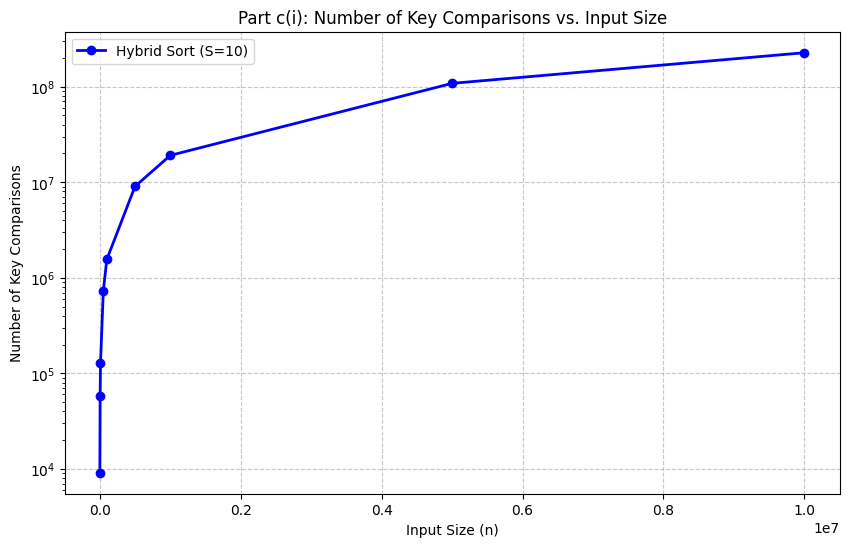

In [16]:
# Run Part c(i)
plot_S_fixed()


Running Part c(ii)...


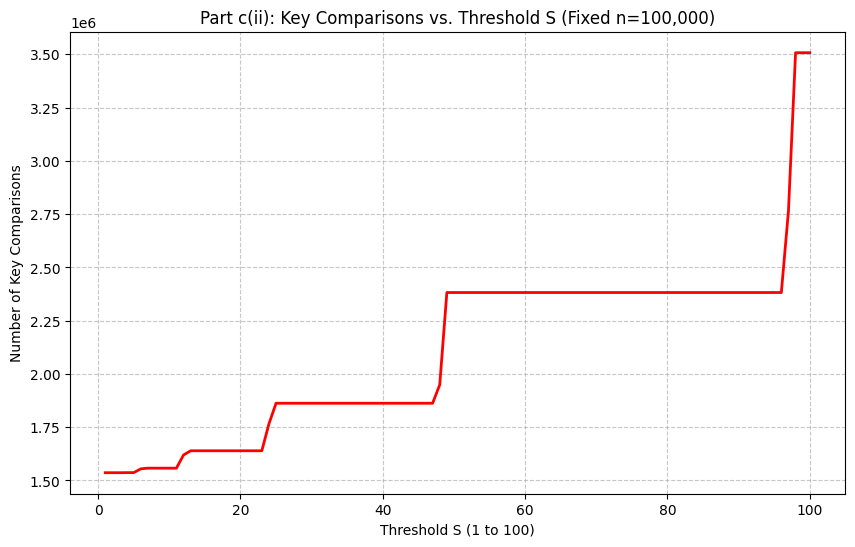

In [17]:
# Run Part c(ii)
plot_S_changes()


Running Part c(iii)... (Testing S = 1 to 29 across all sizes)
Evaluating n = 1,000...
Evaluating n = 5,000...
Evaluating n = 10,000...
Evaluating n = 50,000...
Evaluating n = 100,000...
Evaluating n = 500,000...
Evaluating n = 1,000,000...
Evaluating n = 5,000,000...
Evaluating n = 10,000,000...

Optimal S based on CPU time:
n =      1,000 -> Optimal S =  9 | CPU Time = 0.0018 seconds
n =      5,000 -> Optimal S = 10 | CPU Time = 0.0119 seconds
n =     10,000 -> Optimal S = 17 | CPU Time = 0.0264 seconds
n =     50,000 -> Optimal S = 12 | CPU Time = 0.1685 seconds
n =    100,000 -> Optimal S = 19 | CPU Time = 0.3873 seconds
n =    500,000 -> Optimal S = 23 | CPU Time = 2.5717 seconds
n =  1,000,000 -> Optimal S = 19 | CPU Time = 5.9167 seconds
n =  5,000,000 -> Optimal S = 17 | CPU Time = 41.3649 seconds
n = 10,000,000 -> Optimal S = 19 | CPU Time = 89.9186 seconds


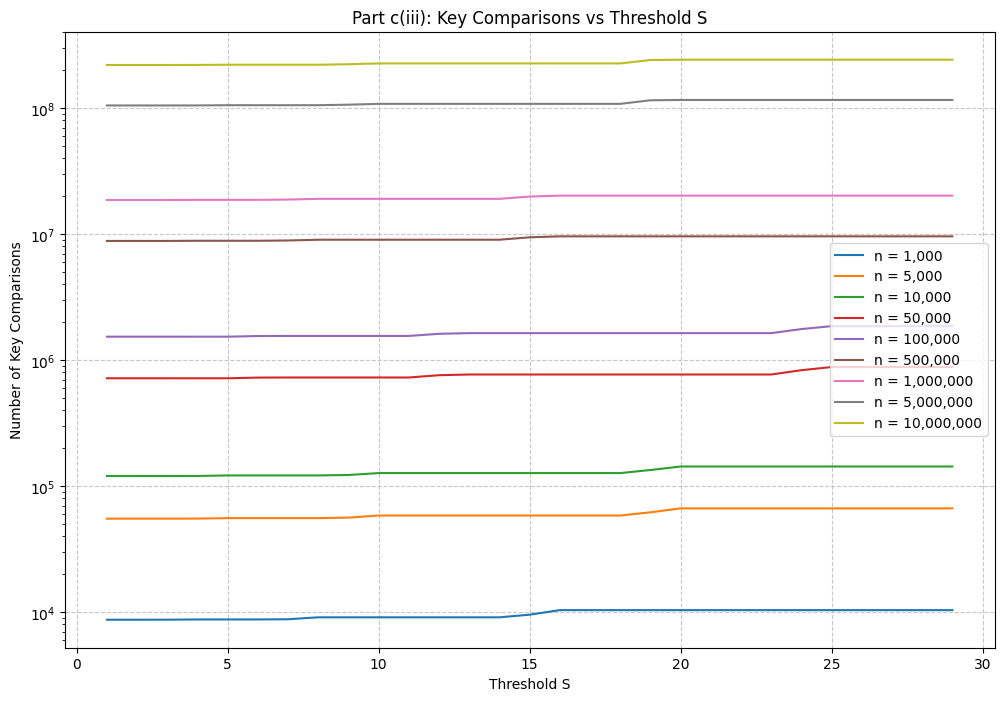

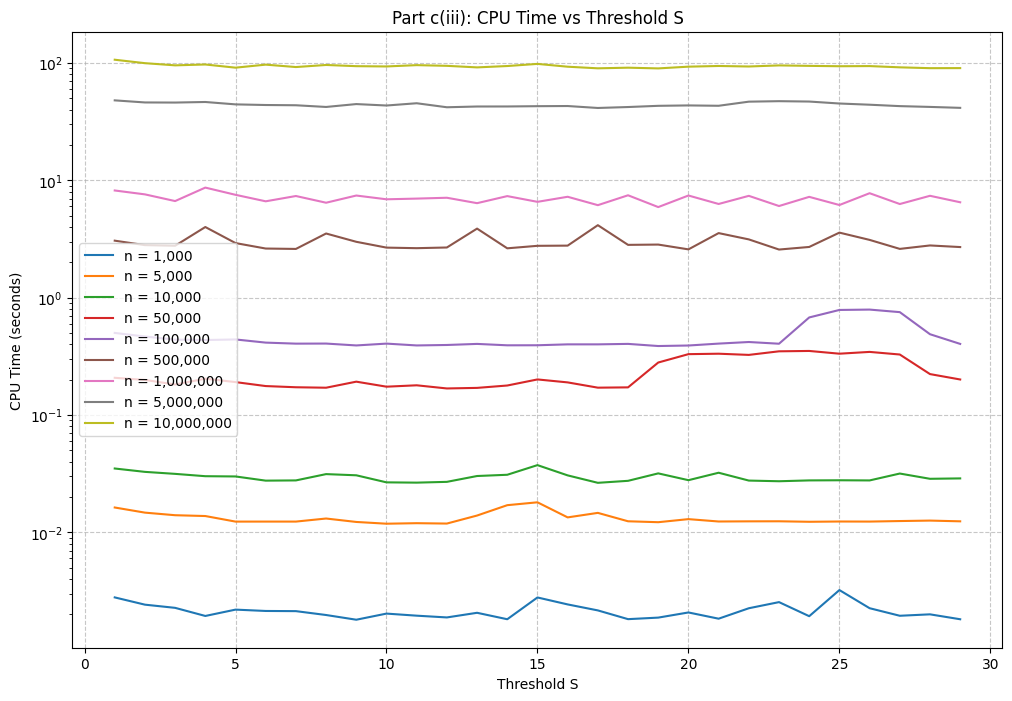

In [18]:
# Run Part c(iii) and capture the optimal S for n = 10,000,000
best_S_10m = optimal_s()

In [19]:
# Run Part (d) using the optimal S determined from c(iii) (typically S = 14)
Merge_vs_Hybrid_sort(optimal_S=best_S_10m)


--- Benchmarking Dataset Size: 10,000,000 ---
Running Original Merge Sort...
Running Hybrid Sort (S=19)...

--- Final Results ---
Original Merge Sort:
  Key Comparisons : 220,101,036
  CPU Time        : 100.4036 seconds

Hybrid Sort (S=19):
  Key Comparisons : 241,007,127
  CPU Time        : 100.8961 seconds

Time Saved: -0.4924s (-0.49% faster)
